# Thực nghiệm Optuna + LightGBM cho dữ liệu time series

So sánh bốn phương pháp:

- **M0**: LightGBM mặc định.
- **M1**: LightGBM + Optuna `RandomSampler`.
- **M2**: LightGBM + Optuna `TPESampler`.
- **M3**: LightGBM + Optuna `TPESampler` + `MedianPruner`.

Thiết kế chính:

- `dev`: 9 năm; `test`: năm cuối.
- Expanding-window validation trên `dev`.
- M1, M2 và M3 dùng cùng search space, objective, folds, số trial và cấu hình LightGBM chung.
- Pruning của M3 được thực hiện sau từng validation fold.
- `search_seed` thay đổi qua nhiều lần chạy; `model_seed` được cố định.
- M1–M3 đều được đề xuất đúng `N_TRIALS`; báo cáo thêm số trial hoàn thành, số trial bị prune và tổng thời gian.


In [ ]:
# Cài đặt thư viện trên Google Colab
!pip -q install -U lightgbm optuna scikit-learn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 20.2 MB/s eta 0:00:00


In [ ]:
import gc
import json
import os
import platform
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy
import sklearn

from lightgbm import LGBMRegressor
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("LightGBM:", lgb.__version__)
print("Optuna:", optuna.__version__)
print("SciPy:", scipy.__version__)


Python: 3.12.13
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.9.0
LightGBM: 4.7.0
Optuna: 4.9.0
SciPy: 1.18.0


In [ ]:
base_url = (
    "https://raw.githubusercontent.com/AIVIETNAM-AIO-TheHien/"
    "Lightgbm-Hyperparameter-Optimization/main/data/processed"
)

dev = pd.read_csv(f"{base_url}/dev.csv", parse_dates=["Date"])
test = pd.read_csv(f"{base_url}/test.csv", parse_dates=["Date"])

target = "Revenue"

feature_cols = [
    column
    for column in dev.columns
    if column not in ["Date", "Revenue", "COGS"]
]

X_dev = dev[feature_cols]
y_dev = dev[target]

X_test = test[feature_cols]
y_test = test[target]

## 1. Cấu hình thực nghiệm

Dựa theo file `dev.csv`:

- cột thời gian là `Date`;
- dữ liệu dev trải từ năm 2013 đến 2021;
- mỗi dòng tương ứng một ngày;
- `Date` đang ở dạng chuỗi, cần chuyển bằng `pd.to_datetime`.

Tập test phải có cùng cột `Date` và phải nằm hoàn toàn sau ngày cuối của dev.


In [ ]:
# =========================
# CẤU HÌNH THỰC NGHIỆM
# =========================

# Trong file dev.csv, cột thời gian có tên chính xác là "Date".
DATE_COL = "Date"

# File dev có 9 năm: 2013–2021.
EXPECTED_N_DEV_YEARS = 9
N_VALID_YEARS = 4

N_TRIALS = 50
SEARCH_SEEDS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

MODEL_SEED = 2026

MAX_BOOST_ROUNDS = 2000
EARLY_STOPPING_ROUNDS = 100

TPE_STARTUP_TRIALS = 10

# MedianPruner ở cấp độ fold.
PRUNER_STARTUP_TRIALS = 10
PRUNER_WARMUP_STEPS = 1
PRUNER_INTERVAL_STEPS = 1
PRUNER_MIN_TRIALS = 5

# LightGBM dùng nhiều CPU thread; Optuna chạy study tuần tự.
LGBM_N_JOBS = -1
OPTUNA_N_JOBS = 1

SHOW_PROGRESS_BAR = False

OUTPUT_DIR = Path("/content/optuna_lgbm_timeseries_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/optuna_lgbm_timeseries_results


## 2. Chuẩn bị dữ liệu theo cấu trúc của `dev.csv`

Cấu trúc cần thiết:

- `Date`: thời gian dạng `YYYY-MM-DD`;
- `target`: tên cột mục tiêu, ví dụ `"Revenue"` hoặc `"COGS"`;
- `feature_cols`: danh sách đặc trưng đầu vào.

Cell sẽ tự động:

1. chuyển `Date` sang `datetime64`;
2. sắp xếp dev và test theo thời gian;
3. loại `Date` và target khỏi tập đặc trưng nếu chúng vô tình nằm trong `feature_cols`;
4. kiểm tra trùng ngày, miền thời gian và tính nhất quán giữa dev/test.


In [ ]:
def prepare_time_dataframe(
    df: pd.DataFrame,
    dataset_name: str,
    date_col: str,
) -> pd.DataFrame:
    prepared = df.copy()

    prepared[date_col] = pd.to_datetime(
        prepared[date_col],
        format="%Y-%m-%d",
        errors="raise",
    )

    prepared = prepared.sort_values(date_col).reset_index(drop=True)

    duplicated_dates = prepared[date_col].duplicated().sum()

    return prepared

dev_sorted = prepare_time_dataframe(
    df=dev,
    dataset_name="dev",
    date_col=DATE_COL,
)

test_sorted = prepare_time_dataframe(
    df=test,
    dataset_name="test",
    date_col=DATE_COL,
)

dev_dates = dev_sorted[DATE_COL].copy()
test_dates = test_sorted[DATE_COL].copy()

# Bảo vệ khỏi data leakage:
# - Date chỉ dùng để sắp xếp và tạo fold;
# - target không được nằm trong X.
model_feature_cols = [
    col
    for col in list(feature_cols)
    if col not in {DATE_COL, target}
]

missing_dev_features = [
    col for col in model_feature_cols
    if col not in dev_sorted.columns
]

missing_test_features = [
    col for col in model_feature_cols
    if col not in test_sorted.columns
]

X_dev = dev_sorted[model_feature_cols].copy()
y_dev = dev_sorted[target].copy()

X_test = test_sorted[model_feature_cols].copy()
y_test = test_sorted[target].copy()

# Sau khi loại Date, file dev hiện tại chủ yếu chứa numeric features.
# Phần xử lý category vẫn được giữ để notebook dùng được nếu bổ sung
# đặc trưng phân loại trong tương lai.
object_cols = X_dev.select_dtypes(include=["object", "string"]).columns.tolist()

for col in object_cols:
    train_categories = pd.Index(X_dev[col].dropna().unique())

    X_dev[col] = pd.Categorical(X_dev[col], categories=train_categories)
    X_test[col] = pd.Categorical(X_test[col],categories=train_categories)

X_dev = X_dev.replace([np.inf, -np.inf],np.nan)
X_test = X_test.replace([np.inf, -np.inf],np.nan)

dev_years = sorted(dev_dates.dt.year.unique().tolist())
test_years = sorted(test_dates.dt.year.unique().tolist())

print("X_dev:", X_dev.shape)
print("X_test:", X_test.shape)
print("Target:", target)
print("Number of model features:", len(model_feature_cols))
print("Dev period:", dev_dates.min(), "→", dev_dates.max())
print("Test period:", test_dates.min(), "→", test_dates.max())
print("Dev years:", dev_years)
print("Test years:", test_years)
print("Object columns converted to category:", object_cols)
print("Missing values in X_dev:", int(X_dev.isna().sum().sum()))
print("Missing values in X_test:", int(X_test.isna().sum().sum()))


X_dev: (3287, 81)
X_test: (365, 81)
Target: Revenue
Number of model features: 81
Dev period: 2013-01-01 00:00:00 → 2021-12-31 00:00:00
Test period: 2022-01-01 00:00:00 → 2022-12-31 00:00:00
Dev years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Test years: [2022]
Object columns converted to category: []
Missing values in X_dev: 0
Missing values in X_test: 0


## 3. Tạo expanding-window splits theo năm

Với file dev hiện tại gồm 2013–2021 và `N_VALID_YEARS=4`, các fold là:

```text
Fold 1: Train 2013–2017 → Validation 2018
Fold 2: Train 2013–2018 → Validation 2019
Fold 3: Train 2013–2019 → Validation 2020
Fold 4: Train 2013–2020 → Validation 2021
```

Tập test phải bắt đầu từ năm 2022 hoặc một thời điểm muộn hơn ngày 31/12/2021.


In [ ]:
def make_yearly_expanding_splits(
    dates: pd.Series,
    n_valid_years: int = 4,
):
    years = np.array(sorted(dates.dt.year.unique()))

    validation_years = years[-n_valid_years:]
    splits = []

    for validation_year in validation_years:
        train_idx = np.flatnonzero(
            dates.dt.year.to_numpy() < validation_year
        )

        valid_idx = np.flatnonzero(
            dates.dt.year.to_numpy() == validation_year
        )

        splits.append((train_idx, valid_idx))

    return splits, years, validation_years


CV_SPLITS, DEV_YEARS, VALIDATION_YEARS = (
    make_yearly_expanding_splits(
        dates=dev_dates,
        n_valid_years=N_VALID_YEARS,
    )
)

print("Dev years:", DEV_YEARS.tolist())
print("Validation years:", VALIDATION_YEARS.tolist())

for fold_id, ((train_idx, valid_idx), valid_year) in enumerate(
    zip(CV_SPLITS, VALIDATION_YEARS),
    start=1,
):
    train_years = sorted(dev_dates.iloc[train_idx].dt.year.unique().tolist())

    train_start = dev_dates.iloc[train_idx].min().date()
    train_end = dev_dates.iloc[train_idx].max().date()
    valid_start = dev_dates.iloc[valid_idx].min().date()
    valid_end = dev_dates.iloc[valid_idx].max().date()

    print(
        f"Fold {fold_id}: "
        f"train={train_years[0]}–{train_years[-1]} "
        f"[{train_start} → {train_end}] "
        f"({len(train_idx):,} samples) → "
        f"validation={valid_year} "
        f"[{valid_start} → {valid_end}] "
        f"({len(valid_idx):,} samples)"
    )


Dev years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Validation years: [2018, 2019, 2020, 2021]
Fold 1: train=2013–2017 [2013-01-01 → 2017-12-31] (1,826 samples) → validation=2018 [2018-01-01 → 2018-12-31] (365 samples)
Fold 2: train=2013–2018 [2013-01-01 → 2018-12-31] (2,191 samples) → validation=2019 [2019-01-01 → 2019-12-31] (365 samples)
Fold 3: train=2013–2019 [2013-01-01 → 2019-12-31] (2,556 samples) → validation=2020 [2020-01-01 → 2020-12-31] (366 samples)
Fold 4: train=2013–2020 [2013-01-01 → 2020-12-31] (2,922 samples) → validation=2021 [2021-01-01 → 2021-12-31] (365 samples)


## 4. Metric và search space chung

Objective chính là mean validation MAE. RMSE được lưu để phân tích bổ sung.

`n_estimators` không nằm trong search space. Mỗi fold bắt đầu với cùng `MAX_BOOST_ROUNDS`, sau đó dùng cùng early stopping. Số cây cuối cùng được lấy bằng trung vị `best_iteration_` qua các fold.


In [ ]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    denominator = np.abs(np.asarray(y_true)) + np.abs(np.asarray(y_pred))
    smape = np.mean(
        np.where(
            denominator == 0,
            0.0,
            2.0 * np.abs(np.asarray(y_pred) - np.asarray(y_true)) / denominator,
        )
    ) * 100.0

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "smape": float(smape),
    }

def suggest_lgbm_params(trial: optuna.Trial):
    return {
        "learning_rate": trial.suggest_float(
            "learning_rate", 5e-3, 2e-1, log=True
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", 16, 256, log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 4, 16
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 10, 200, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        ),
    }

def common_lgbm_params():
    return {
        "objective": "regression",
        "n_estimators": MAX_BOOST_ROUNDS,
        "subsample_freq": 1,
        "random_state": MODEL_SEED,
        "n_jobs": LGBM_N_JOBS,
        "verbosity": -1,
        "deterministic": True,
        "force_col_wise": True,
    }

def build_lgbm_model(tuned_params=None, n_estimators=None):
    params = common_lgbm_params()

    if tuned_params:
        params.update(tuned_params)

    if n_estimators is not None:
        params["n_estimators"] = max(1, int(n_estimators))

    return LGBMRegressor(**params)

## 5. Objective chung cho M1, M2 và M3

M3 dùng fold-level pruning:

1. Huấn luyện và đánh giá một validation fold.
2. Báo cáo mean MAE tạm thời bằng `trial.report`.
3. `MedianPruner` có thể dừng trial trước khi chạy các fold còn lại.

M1 và M2 gọi đúng cùng hàm nhưng đặt `enable_pruning=False`.


In [ ]:
def evaluate_params_with_cv(
    tuned_params,
    trial=None,
    enable_pruning=False,
):
    fold_records = []
    best_iterations = []

    for fold_idx, ((train_idx, valid_idx), valid_year) in enumerate(
        zip(CV_SPLITS, VALIDATION_YEARS)
    ):
        X_train_fold = X_dev.iloc[train_idx]
        y_train_fold = y_dev.iloc[train_idx]

        X_valid_fold = X_dev.iloc[valid_idx]
        y_valid_fold = y_dev.iloc[valid_idx]

        model = build_lgbm_model(tuned_params=tuned_params)

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_X=X_valid_fold,
            eval_y=y_valid_fold,
            eval_names=["valid"],
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=EARLY_STOPPING_ROUNDS,
                    first_metric_only=True,
                    verbose=False,
                ),
                lgb.log_evaluation(period=0),
            ],
        )

        best_iteration = (
            int(model.best_iteration_)
            if getattr(model, "best_iteration_", None)
            else MAX_BOOST_ROUNDS
        )

        prediction = model.predict(
            X_valid_fold,
            num_iteration=best_iteration,
        )

        metrics = regression_metrics(y_valid_fold, prediction)

        fold_records.append(
            {
                "fold": fold_idx,
                "validation_year": int(valid_year),
                "mae": metrics["mae"],
                "rmse": metrics["rmse"],
                "smape": metrics["smape"],
                "best_iteration": best_iteration,
            }
        )
        best_iterations.append(best_iteration)

        if trial is not None:
            running_mean_mae = float(
                np.mean([record["mae"] for record in fold_records])
            )
            trial.set_user_attr(
                f"fold_{fold_idx}_validation_year",
                int(valid_year),
            )
            trial.set_user_attr(
                f"fold_{fold_idx}_mae",
                float(metrics["mae"]),
            )

            if enable_pruning:
                trial.report(
                    running_mean_mae,
                    step=fold_idx,
                )

                if trial.should_prune():
                    raise optuna.TrialPruned(
                        f"Pruned after fold {fold_idx + 1}; "
                        f"running mean MAE={running_mean_mae:.6f}"
                    )

        del model
        gc.collect()

    mean_mae = float(np.mean([record["mae"] for record in fold_records]))
    mean_rmse = float(np.mean([record["rmse"] for record in fold_records]))
    mean_smape = float(np.mean([record["smape"] for record in fold_records]))
    median_best_iteration = int(np.median(best_iterations))

    return {
        "mean_mae": mean_mae,
        "mean_rmse": mean_rmse,
        "mean_smape": mean_smape,
        "median_best_iteration": median_best_iteration,
        "fold_records": fold_records,
    }


def make_objective(enable_pruning=False):
    def objective(trial):
        tuned_params = suggest_lgbm_params(trial)

        cv_result = evaluate_params_with_cv(
            tuned_params=tuned_params,
            trial=trial,
            enable_pruning=enable_pruning,
        )

        trial.set_user_attr(
            "median_best_iteration",
            cv_result["median_best_iteration"],
        )
        trial.set_user_attr(
            "mean_cv_rmse",
            cv_result["mean_rmse"],
        )
        trial.set_user_attr(
            "mean_cv_smape",
            cv_result["mean_smape"],
        )
        trial.set_user_attr(
            "fold_records",
            cv_result["fold_records"],
        )

        return cv_result["mean_mae"]

    return objective


## 6. M0: LightGBM mặc định

M0 dùng các siêu tham số mặc định của `LGBMRegressor`, ngoại trừ các thiết lập kỹ thuật để cố định seed, số CPU thread, chế độ deterministic và tắt log.

M0 không dùng Optuna và không dùng validation để chọn cấu hình.


In [ ]:
def run_default_lightgbm():
    start_time = time.perf_counter()

    # Không truyền các siêu tham số thuộc search space.
    model = LGBMRegressor(
        random_state=MODEL_SEED,
        n_jobs=LGBM_N_JOBS,
        verbosity=-1,
        deterministic=True,
        force_col_wise=True,
    )

    fit_start = time.perf_counter()
    model.fit(X_dev, y_dev)
    fit_seconds = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    prediction = model.predict(X_test)
    predict_seconds = time.perf_counter() - predict_start

    metrics = regression_metrics(y_test, prediction)
    total_seconds = time.perf_counter() - start_time

    result = {
        "method": "M0_Default",
        "search_seed": np.nan,
        "model_seed": MODEL_SEED,
        "n_trials_proposed": 0,
        "n_complete": 0,
        "n_pruned": 0,
        "best_cv_mae": np.nan,
        "best_cv_rmse": np.nan,
        "best_iteration": int(model.n_estimators_),
        "search_time_seconds": 0.0,
        "final_fit_seconds": float(fit_seconds),
        "prediction_seconds": float(predict_seconds),
        "total_seconds": float(total_seconds),
        "test_mae": metrics["mae"],
        "test_rmse": metrics["rmse"],
        "test_smape": metrics["smape"],
        "best_params": json.dumps(
            model.get_params(deep=False),
            default=str,
            ensure_ascii=False,
        ),
    }

    return result, prediction, model


m0_result, m0_prediction, m0_model = run_default_lightgbm()
pd.DataFrame([m0_result])


,method,search_seed,model_seed,n_trials_proposed,n_complete,n_pruned,best_cv_mae,best_cv_rmse,best_iteration,search_time_seconds,final_fit_seconds,prediction_seconds,total_seconds,test_mae,test_rmse,test_smape,best_params
0,M0_Default,NaN,2026,0,0,0,NaN,NaN,100,0.0,0.898188,0.008455,1.031107,590485.237784,794592.382269,20.423753,"{""boosting_type"": ""gbdt"", ""class_weight"": null..."


## 7. Hàm chạy M1, M2 và M3

M1, M2 và M3:

- cùng `N_TRIALS`;
- cùng search space;
- cùng objective;
- cùng expanding-window folds;
- cùng early stopping;
- cùng `MODEL_SEED`;
- chạy Optuna tuần tự.

Khác biệt:

- M1: `RandomSampler` + `NopPruner`;
- M2: `TPESampler` + `NopPruner`;
- M3: `TPESampler` + `MedianPruner`.


In [ ]:
def create_study(method, search_seed):
    if method == "M1_Random":
        sampler = optuna.samplers.RandomSampler(seed=search_seed)
        pruner = optuna.pruners.NopPruner()
        enable_pruning = False

    elif method == "M2_TPE":
        sampler = optuna.samplers.TPESampler(
            seed=search_seed,
            n_startup_trials=TPE_STARTUP_TRIALS,
        )
        pruner = optuna.pruners.NopPruner()
        enable_pruning = False

    elif method == "M3_TPE_Pruning":
        sampler = optuna.samplers.TPESampler(
            seed=search_seed,
            n_startup_trials=TPE_STARTUP_TRIALS,
        )
        pruner = optuna.pruners.MedianPruner(
            n_startup_trials=PRUNER_STARTUP_TRIALS,
            n_warmup_steps=PRUNER_WARMUP_STEPS,
            interval_steps=PRUNER_INTERVAL_STEPS,
            n_min_trials=PRUNER_MIN_TRIALS,
        )
        enable_pruning = True

    else:
        raise ValueError(f"Phương pháp không hợp lệ: {method}")

    study = optuna.create_study(
        study_name=f"{method}_seed_{search_seed}",
        direction="minimize",
        sampler=sampler,
        pruner=pruner,
    )

    return study, enable_pruning


def fit_final_model(best_params, best_iteration):
    model = build_lgbm_model(
        tuned_params=best_params,
        n_estimators=best_iteration,
    )

    fit_start = time.perf_counter()
    model.fit(X_dev, y_dev)
    fit_seconds = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    prediction = model.predict(X_test)
    predict_seconds = time.perf_counter() - predict_start

    metrics = regression_metrics(y_test, prediction)

    return model, prediction, metrics, fit_seconds, predict_seconds


def study_convergence_records(study, method, search_seed):
    records = []
    best_so_far = np.inf
    study_start = min(
        trial.datetime_start
        for trial in study.trials
        if trial.datetime_start is not None
    )

    for trial in sorted(study.trials, key=lambda item: item.number):
        if (
            trial.state == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
        ):
            best_so_far = min(best_so_far, float(trial.value))

        elapsed_seconds = np.nan
        if trial.datetime_complete is not None:
            elapsed_seconds = (
                trial.datetime_complete - study_start
            ).total_seconds()

        records.append(
            {
                "method": method,
                "search_seed": search_seed,
                "trial_number": trial.number,
                "trial_state": trial.state.name,
                "trial_value": (
                    float(trial.value)
                    if trial.value is not None
                    else np.nan
                ),
                "best_cv_mae_so_far": (
                    float(best_so_far)
                    if np.isfinite(best_so_far)
                    else np.nan
                ),
                "elapsed_seconds": elapsed_seconds,
            }
        )

    return records


In [ ]:
from optuna.trial import TrialState

def make_trial_callback(
    method: str,
    search_seed: int,
    total_trials: int,
):
    """
    Tạo callback hiển thị kết quả sau mỗi trial.

    Callback hoạt động với các trạng thái:
    - COMPLETE
    - PRUNED
    - FAIL
    """

    study_start_time = time.perf_counter()

    def callback(
        study: optuna.study.Study,
        trial: optuna.trial.FrozenTrial,
    ):
        trial_number = trial.number + 1
        state = trial.state.name

        # Thời gian của trial hiện tại
        if trial.duration is not None:
            trial_seconds = trial.duration.total_seconds()
        else:
            trial_seconds = np.nan

        # Tổng thời gian từ đầu study
        elapsed_seconds = (time.perf_counter() - study_start_time)

        # Giá trị objective của trial
        if trial.value is not None:
            trial_value_text = f"{trial.value:.6f}"
        elif trial.intermediate_values:
            last_step = max(trial.intermediate_values)
            last_value = trial.intermediate_values[last_step]
            trial_value_text = f"{last_value:.6f}"
        else:
            trial_value_text = "N/A"

        # Best value chỉ được xác định khi có ít nhất một trial COMPLETE
        completed_trials = [
            completed_trial
            for completed_trial in study.trials
            if (
                completed_trial.state == TrialState.COMPLETE
                and completed_trial.value is not None
            )
        ]

        if completed_trials:
            best_value_text = f"{study.best_value:.6f}"
        else:
            best_value_text = "N/A"

        n_complete = sum(
            completed_trial.state == TrialState.COMPLETE
            for completed_trial in study.trials
        )

        n_pruned = sum(
            completed_trial.state == TrialState.PRUNED
            for completed_trial in study.trials
        )

        n_failed = sum(
            completed_trial.state == TrialState.FAIL
            for completed_trial in study.trials
        )

        print(
            f"[{method}] "
            f"[seed={search_seed}] "
            f"Trial {trial_number}/{total_trials} | "
            f"state={state} | "
            f"value={trial_value_text} | "
            f"best={best_value_text} | "
            f"trial_time={trial_seconds:.2f}s | "
            f"elapsed={elapsed_seconds:.2f}s | "
            f"complete={n_complete} | "
            f"pruned={n_pruned} | "
            f"failed={n_failed}",
            flush=True,
        )

    return callback

In [ ]:
def run_optimization_method(
    method,
    search_seed,
):
    study, enable_pruning = create_study(
        method=method,
        search_seed=search_seed,
    )

    trial_callback = make_trial_callback(
        method=method,
        search_seed=search_seed,
        total_trials=N_TRIALS,
    )

    search_start = time.perf_counter()

    study.optimize(
        make_objective(
            enable_pruning=enable_pruning
        ),
        n_trials=N_TRIALS,
        n_jobs=OPTUNA_N_JOBS,
        show_progress_bar=False,
        gc_after_trial=True,
        callbacks=[trial_callback],
    )

    search_seconds = (time.perf_counter() - search_start)

    best_trial = study.best_trial

    best_iteration = int(best_trial.user_attrs["median_best_iteration"])

    (
        final_model,
        prediction,
        test_metrics,
        fit_seconds,
        predict_seconds,
    ) = fit_final_model(
        best_params=study.best_params,
        best_iteration=best_iteration,
    )

    n_complete = sum(
        trial.state
        == optuna.trial.TrialState.COMPLETE
        for trial in study.trials
    )

    n_pruned = sum(
        trial.state
        == optuna.trial.TrialState.PRUNED
        for trial in study.trials
    )

    n_failed = sum(
        trial.state
        == optuna.trial.TrialState.FAIL
        for trial in study.trials
    )

    result = {
        "method": method,
        "search_seed": search_seed,
        "model_seed": MODEL_SEED,
        "n_trials_proposed": len(study.trials),
        "n_complete": n_complete,
        "n_pruned": n_pruned,
        "n_failed": n_failed,
        "best_cv_mae": float(study.best_value),
        "best_cv_rmse": float(best_trial.user_attrs["mean_cv_rmse"]),
        "best_iteration": (best_iteration),
        "search_time_seconds": float(search_seconds),
        "final_fit_seconds": float(fit_seconds),
        "prediction_seconds": float(predict_seconds),
        "total_seconds": float(search_seconds + fit_seconds + predict_seconds),
        "test_mae": (test_metrics["mae"]),
        "test_rmse": (test_metrics["rmse"]),
        "test_smape": (test_metrics["smape"]),
        "best_params": json.dumps(
            study.best_params,
            default=str,
            ensure_ascii=False,
        ),
    }

    return {
        "result": result,
        "study": study,
        "prediction": prediction,
        "model": final_model,
        "convergence": (
            study_convergence_records(
                study=study,
                method=method,
                search_seed=search_seed,
            )
        ),
    }

## 8. Chạy toàn bộ thực nghiệm

```python
N_TRIALS = 50
SEARCH_SEEDS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
```

In [ ]:
METHODS = [
    "M1_Random",
    "M2_TPE",
    "M3_TPE_Pruning",
]

all_results = [m0_result]
all_convergence = []

# Lưu prediction của từng lần chạy nếu cần phân tích theo thời điểm.
prediction_store = {
    ("M0_Default", None): np.asarray(m0_prediction)
}

# Lưu study/model trong RAM chỉ cho lần chạy hiện tại.
# Kết quả tabular được ghi ra ổ đĩa sau mỗi seed.
latest_studies = {}
latest_models = {}

for search_seed in SEARCH_SEEDS:
    print(f"\n{'=' * 70}")
    print(f"SEARCH SEED = {search_seed}")
    print(f"{'=' * 70}")

    for method in METHODS:
        print(f"Running {method} ...")

        run_output = run_optimization_method(
            method=method,
            search_seed=search_seed,
        )

        result = run_output["result"]
        all_results.append(result)
        all_convergence.extend(run_output["convergence"])

        prediction_store[(method, search_seed)] = np.asarray(
            run_output["prediction"]
        )
        latest_studies[(method, search_seed)] = run_output["study"]
        latest_models[(method, search_seed)] = run_output["model"]

        results_df = pd.DataFrame(all_results)
        convergence_df = pd.DataFrame(all_convergence)

        results_df.to_csv(
            OUTPUT_DIR / "experiment_results_partial.csv",
            index=False,
        )
        convergence_df.to_csv(
            OUTPUT_DIR / "convergence_partial.csv",
            index=False,
        )

        run_output["study"].trials_dataframe(
            attrs=(
                "number",
                "value",
                "datetime_start",
                "datetime_complete",
                "duration",
                "params",
                "user_attrs",
                "state",
            )
        ).to_csv(
            OUTPUT_DIR
            / f"trials_{method}_seed_{search_seed}.csv",
            index=False,
        )

        with open(
            OUTPUT_DIR / f"best_params_{method}_seed_{search_seed}.json",
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                {
                    "method": method,
                    "search_seed": search_seed,
                    "model_seed": MODEL_SEED,
                    "best_value": run_output["study"].best_value,
                    "best_params": run_output["study"].best_params,
                    "best_trial_user_attrs": (
                        run_output["study"].best_trial.user_attrs
                    ),
                },
                file,
                ensure_ascii=False,
                indent=2,
                default=str,
            )

        print(
            f"  best CV MAE={result['best_cv_mae']:.6f} | "
            f"test MAE={result['test_mae']:.6f} | "
            f"time={result['search_time_seconds']:.2f}s | "
            f"complete={result['n_complete']} | "
            f"pruned={result['n_pruned']}"
        )

        gc.collect()

results_df = pd.DataFrame(all_results)
convergence_df = pd.DataFrame(all_convergence)

results_df.to_csv(
    OUTPUT_DIR / "experiment_results.csv",
    index=False,
)
convergence_df.to_csv(
    OUTPUT_DIR / "convergence.csv",
    index=False,
)

print("\nCompleted.")
display(results_df)



SEARCH SEED = 10
Running M1_Random ...
[M1_Random] [seed=10] Trial 1/50 | state=COMPLETE | value=922567.184716 | best=922567.184716 | trial_time=3.30s | elapsed=3.40s | complete=1 | pruned=0 | failed=0
[M1_Random] [seed=10] Trial 2/50 | state=COMPLETE | value=1074536.503543 | best=922567.184716 | trial_time=5.23s | elapsed=8.73s | complete=2 | pruned=0 | failed=0
[M1_Random] [seed=10] Trial 3/50 | state=COMPLETE | value=956832.961916 | best=922567.184716 | trial_time=1.89s | elapsed=10.73s | complete=3 | pruned=0 | failed=0
[M1_Random] [seed=10] Trial 4/50 | state=COMPLETE | value=943948.485692 | best=922567.184716 | trial_time=7.18s | elapsed=18.02s | complete=4 | pruned=0 | failed=0
[M1_Random] [seed=10] Trial 5/50 | state=COMPLETE | value=927330.896331 | best=922567.184716 | trial_time=1.49s | elapsed=19.62s | complete=5 | pruned=0 | failed=0
[M1_Random] [seed=10] Trial 6/50 | state=COMPLETE | value=1004052.600097 | best=922567.184716 | trial_time=2.40s | elapsed=22.12s | complete=

,method,search_seed,model_seed,n_trials_proposed,n_complete,n_pruned,best_cv_mae,best_cv_rmse,best_iteration,search_time_seconds,final_fit_seconds,prediction_seconds,total_seconds,test_mae,test_rmse,test_smape,best_params,n_failed
0,M0_Default,NaN,2026,0,0,0,NaN,NaN,100,0.000000,0.898188,0.008455,1.031107,590485.237784,794592.382269,20.423753,"{""boosting_type"": ""gbdt"", ""class_weight"": null...",NaN
1,M1_Random,10.0,2026,50,50,0,875781.260743,1.183543e+06,643,258.429989,1.401569,0.014890,259.846448,574916.172382,786881.652505,19.799645,"{""learning_rate"": 0.016613425030836064, ""num_l...",0.0
2,M2_TPE,10.0,2026,50,50,0,834098.628215,1.141492e+06,120,234.926518,0.214099,0.003521,235.144138,567512.577030,772471.861523,19.607857,"{""learning_rate"": 0.11040994955020471, ""num_le...",0.0
3,M3_TPE_Pruning,10.0,2026,50,39,11,834098.628215,1.141492e+06,120,232.733798,0.263002,0.009053,233.005852,567512.577030,772471.861523,19.607857,"{""learning_rate"": 0.11040994955020471, ""num_le...",0.0
4,M1_Random,20.0,2026,50,50,0,855657.433883,1.162485e+06,320,291.533984,0.489374,0.006420,292.029778,546373.876395,751108.375764,18.663410,"{""learning_rate"": 0.03512544452870318, ""num_le...",0.0
5,M2_TPE,20.0,2026,50,50,0,834296.020265,1.139130e+06,1000,304.104551,1.593098,0.022739,305.720388,560062.390643,765178.908609,19.399970,"{""learning_rate"": 0.0146135826677712, ""num_lea...",0.0
6,M3_TPE_Pruning,20.0,2026,50,37,13,834296.020265,1.139130e+06,1000,299.847559,3.694722,0.023421,303.565702,560062.390643,765178.908609,19.399970,"{""learning_rate"": 0.0146135826677712, ""num_lea...",0.0
7,M1_Random,30.0,2026,50,50,0,865176.015343,1.169436e+06,1797,318.169660,3.054254,0.043831,321.267745,550980.155389,755079.115992,18.893062,"{""learning_rate"": 0.006365293815346603, ""num_l...",0.0
8,M2_TPE,30.0,2026,50,50,0,828592.190072,1.125469e+06,1344,610.020801,3.708115,0.059284,613.788200,567009.321194,767703.353431,19.437251,"{""learning_rate"": 0.00948756539300299, ""num_le...",0.0
9,M3_TPE_Pruning,30.0,2026,50,36,14,828592.190072,1.125469e+06,1344,604.918247,3.392726,0.030087,608.341060,567009.321194,767703.353431,19.437251,"{""learning_rate"": 0.00948756539300299, ""num_le...",0.0


## 9. Tổng hợp trung bình, độ lệch chuẩn và khoảng tin cậy 95%


In [ ]:
summary_rows = []

for method, group in results_df.groupby("method", sort=False):
    summary_rows.append(
        {
            "method": method,
            "n_runs": len(group),
            "test_mae_mean": group["test_mae"].mean(),
            "test_mae_std": group["test_mae"].std(ddof=1),
            "test_rmse_mean": group["test_rmse"].mean(),
            "test_rmse_std": group["test_rmse"].std(ddof=1),
            "test_smape_mean": group["test_smape"].mean(),
            "search_time_mean_seconds": (
                group["search_time_seconds"].mean()
            ),
            "search_time_std_seconds": (
                group["search_time_seconds"].std(ddof=1)
            ),
            "total_time_mean_seconds": group["total_seconds"].mean(),
            "complete_trials_mean": group["n_complete"].mean(),
            "pruned_trials_mean": group["n_pruned"].mean(),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(
    OUTPUT_DIR / "summary.csv",
    index=False,
)

display(summary_df)


,method,n_runs,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,test_smape_mean,search_time_mean_seconds,search_time_std_seconds,total_time_mean_seconds,complete_trials_mean,pruned_trials_mean
0,M0_Default,1,590485.237784,NaN,794592.382269,NaN,20.423753,0.000000,NaN,1.031107,0.0,0.0
1,M1_Random,10,559165.854800,12422.243230,768310.135284,16722.171886,19.266829,323.773434,46.435440,324.867960,50.0,0.0
2,M2_TPE,10,563656.361127,6124.238936,767238.840015,5887.635498,19.473151,346.329142,137.988662,347.886906,50.0,0.0
3,M3_TPE_Pruning,10,563656.361127,6124.238936,767238.840015,5887.635498,19.473151,343.308710,136.795845,345.404938,38.6,11.4


In [ ]:
METHOD_ORDER = [
    "M0_Default",
    "M1_Random",
    "M2_TPE",
    "M3_TPE_Pruning",
]

METHOD_LABELS = {
    "M0_Default": "LightGBM mặc định",
    "M1_Random": "LightGBM + RandomSampler",
    "M2_TPE": "LightGBM + TPESampler",
    "M3_TPE_Pruning": "LightGBM + TPESampler + Pruning",
}

METRICS = {
    "test_mae": "MAE",
    "test_rmse": "RMSE",
    "test_smape": "sMAPE",
}

# Tính giá trị trung bình qua các seed
metric_summary = (
    results_df
    .groupby("method")[list(METRICS)]
    .mean()
    .reindex(METHOD_ORDER)
)

# Giá trị baseline M0
baseline = metric_summary.loc["M0_Default"]

comparison_table = pd.DataFrame(index=metric_summary.index)

comparison_table["Phương pháp"] = (comparison_table.index.map(METHOD_LABELS))

for metric_col, metric_name in METRICS.items():
    comparison_table[metric_name] = metric_summary[metric_col]

    comparison_table[f"Cải thiện {metric_name} (%)"] = (
        ( baseline[metric_col] - metric_summary[metric_col])
        / baseline[metric_col]
        * 100
    )

comparison_table = comparison_table.reset_index(drop=True)

# Thứ tự cột gọn, dễ đối chiếu
comparison_table = comparison_table[
    [
        "Phương pháp",
        "MAE",
        "Cải thiện MAE (%)",
        "RMSE",
        "Cải thiện RMSE (%)",
        "sMAPE",
        "Cải thiện sMAPE (%)",
    ]
]

# Bảng hiển thị
display(
    comparison_table.style.format(
        {
            "MAE": "{:,.0f}",
            "Cải thiện MAE (%)": "{:+.2f}",
            "RMSE": "{:,.0f}",
            "Cải thiện RMSE (%)": "{:+.2f}",
            "sMAPE": "{:.3f}",
            "Cải thiện sMAPE (%)": "{:+.2f}",
        }
    )
)

# Lưu kết quả
comparison_table.to_csv(
    OUTPUT_DIR / "test_metric_improvement.csv",
    index=False,
    encoding="utf-8-sig",
)

,Phương pháp,MAE,Cải thiện MAE (%),RMSE,Cải thiện RMSE (%),sMAPE,Cải thiện sMAPE (%)
0,LightGBM mặc định,"590,485",+0.00,"794,592",+0.00,20.424,+0.00
1,LightGBM + RandomSampler,"559,166",+5.30,"768,310",+3.31,19.267,+5.66
2,LightGBM + TPESampler,"563,656",+4.54,"767,239",+3.44,19.473,+4.65
3,LightGBM + TPESampler + Pruning,"563,656",+4.54,"767,239",+3.44,19.473,+4.65


## 10. So sánh ghép cặp theo cùng search seed

- `M1_Random - M2_TPE > 0`: TPE có MAE thấp hơn RandomSampler.
- `M2_TPE - M3_TPE_Pruning > 0`: TPE + pruning có MAE thấp hơn TPE không pruning.
- Với thời gian, hiệu số dương nghĩa là phương pháp bên phải nhanh hơn.


In [ ]:
search_results = results_df[results_df["method"].isin(METHODS)].copy()

mae_pivot = search_results.pivot(
    index="search_seed",
    columns="method",
    values="test_mae",
)

time_pivot = search_results.pivot(
    index="search_seed",
    columns="method",
    values="search_time_seconds",
)

paired_df = pd.DataFrame(index=mae_pivot.index)

paired_df["mae_M1_minus_M2"] = (mae_pivot["M1_Random"] - mae_pivot["M2_TPE"])
paired_df["mae_M2_minus_M3"] = (mae_pivot["M2_TPE"] - mae_pivot["M3_TPE_Pruning"])

paired_df["time_M1_minus_M2_seconds"] = (time_pivot["M1_Random"] - time_pivot["M2_TPE"])
paired_df["time_M2_minus_M3_seconds"] = (time_pivot["M2_TPE"] - time_pivot["M3_TPE_Pruning"])

paired_df.to_csv(OUTPUT_DIR / "paired_differences.csv")

display(paired_df)
display(paired_df.agg(["mean", "std", "median"]))


def safe_wilcoxon(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2 or np.allclose(x, y):
        return {
            "n": len(x),
            "statistic": np.nan,
            "p_value": np.nan,
        }

    result = stats.wilcoxon(
        x,
        y,
        alternative="two-sided",
    )

    return {
        "n": len(x),
        "statistic": float(result.statistic),
        "p_value": float(result.pvalue),
    }

,mae_M1_minus_M2,mae_M2_minus_M3,time_M1_minus_M2_seconds,time_M2_minus_M3_seconds
search_seed,,,,
10.0,7403.595352,0.0,23.503470,2.192721
20.0,-13688.514247,0.0,-12.570567,4.256992
30.0,-16029.165805,0.0,-291.851140,5.102554
40.0,205.385483,0.0,-45.810221,8.104212
50.0,-11034.791299,0.0,153.639025,-1.082704
60.0,-9492.893478,0.0,97.993108,1.025160
70.0,12032.007833,0.0,-5.378931,-0.022417
80.0,7706.980955,0.0,-56.804595,1.827842
90.0,-12776.132854,0.0,-168.171191,1.594933


,mae_M1_minus_M2,mae_M2_minus_M3,time_M1_minus_M2_seconds,time_M2_minus_M3_seconds
mean,-4490.506327,0.0,-22.555708,3.020432
std,10338.803616,0.0,130.820651,3.044762
median,-9362.214346,0.0,-8.974749,2.010281


## 11. Biểu đồ kết quả


<Figure size 900x500 with 0 Axes>

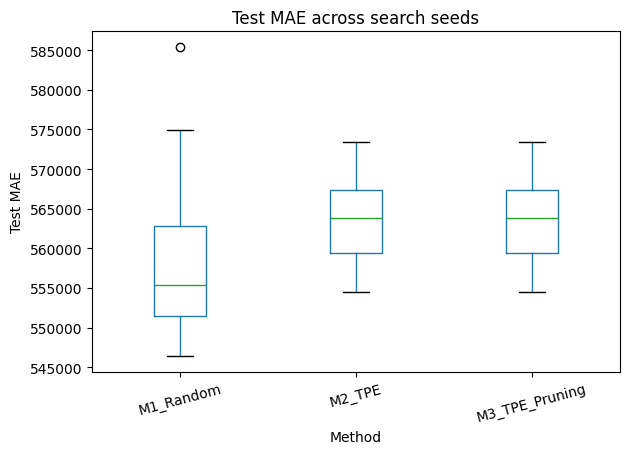

<Figure size 900x500 with 0 Axes>

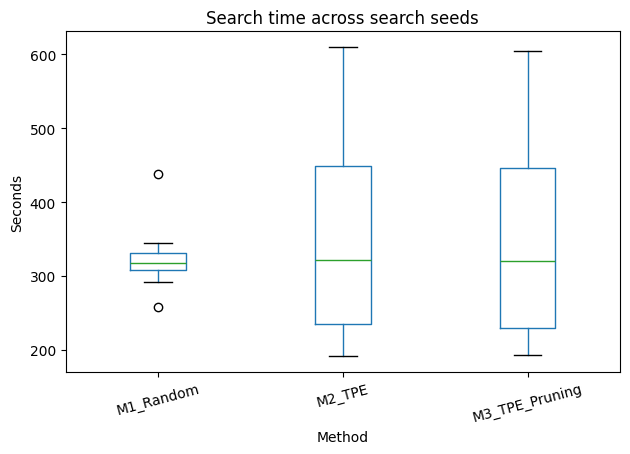

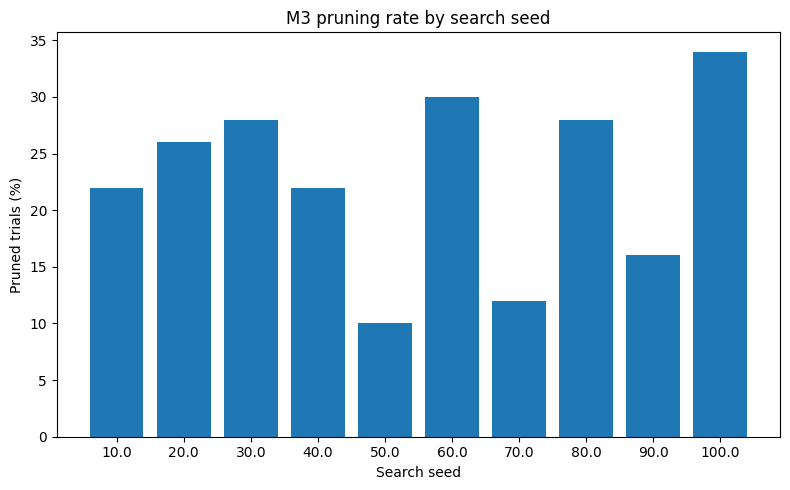

In [ ]:
plot_results = results_df[
    results_df["method"].isin(METHODS)
].copy()

# 1. Phân phối test MAE qua các search seed
plt.figure(figsize=(9, 5))
plot_results.boxplot(
    column="test_mae",
    by="method",
    grid=False,
)
plt.title("Test MAE across search seeds")
plt.suptitle("")
plt.xlabel("Method")
plt.ylabel("Test MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2. Thời gian search theo phương pháp
plt.figure(figsize=(9, 5))
plot_results.boxplot(
    column="search_time_seconds",
    by="method",
    grid=False,
)
plt.title("Search time across search seeds")
plt.suptitle("")
plt.xlabel("Method")
plt.ylabel("Seconds")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 3. Tỷ lệ trial bị prune của M3
m3_results = plot_results[
    plot_results["method"] == "M3_TPE_Pruning"
].copy()

if not m3_results.empty:
    prune_rate = (
        m3_results["n_pruned"]
        / m3_results["n_trials_proposed"]
        * 100.0
    )

    plt.figure(figsize=(8, 5))
    plt.bar(
        m3_results["search_seed"].astype(str),
        prune_rate,
    )
    plt.title("M3 pruning rate by search seed")
    plt.xlabel("Search seed")
    plt.ylabel("Pruned trials (%)")
    plt.tight_layout()
    plt.show()


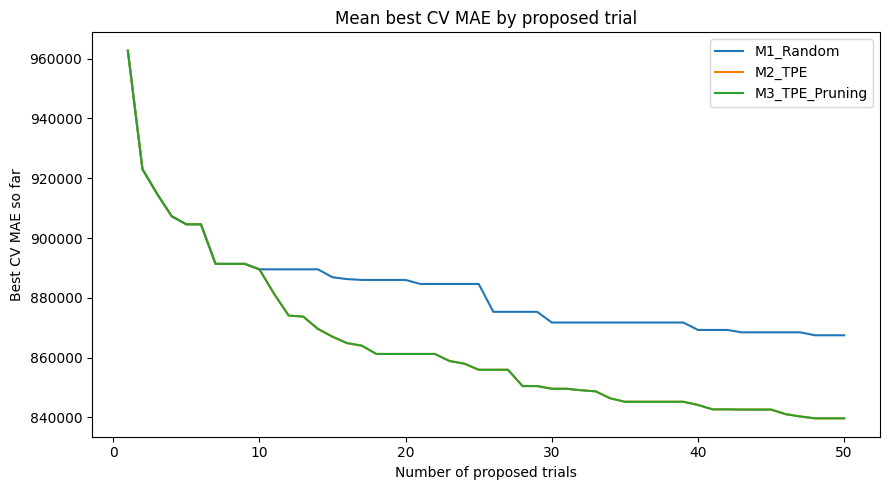

In [ ]:
# 4. Mean best-so-far CV MAE theo trial number
valid_convergence = convergence_df.dropna(
    subset=["best_cv_mae_so_far"]
).copy()

mean_convergence = (
    valid_convergence
    .groupby(["method", "trial_number"], as_index=False)
    ["best_cv_mae_so_far"]
    .mean()
)

plt.figure(figsize=(9, 5))

for method in METHODS:
    method_data = mean_convergence[
        mean_convergence["method"] == method
    ]
    plt.plot(
        method_data["trial_number"] + 1,
        method_data["best_cv_mae_so_far"],
        label=method,
    )

plt.title("Mean best CV MAE by proposed trial")
plt.xlabel("Number of proposed trials")
plt.ylabel("Best CV MAE so far")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_1544/590128556.py:52: RuntimeWarning: Mean of empty slice
  mean_values = np.nanmean(
/tmp/ipykernel_1544/590128556.py:52: RuntimeWarning: Mean of empty slice
  mean_values = np.nanmean(
/tmp/ipykernel_1544/590128556.py:52: RuntimeWarning: Mean of empty slice
  mean_values = np.nanmean(


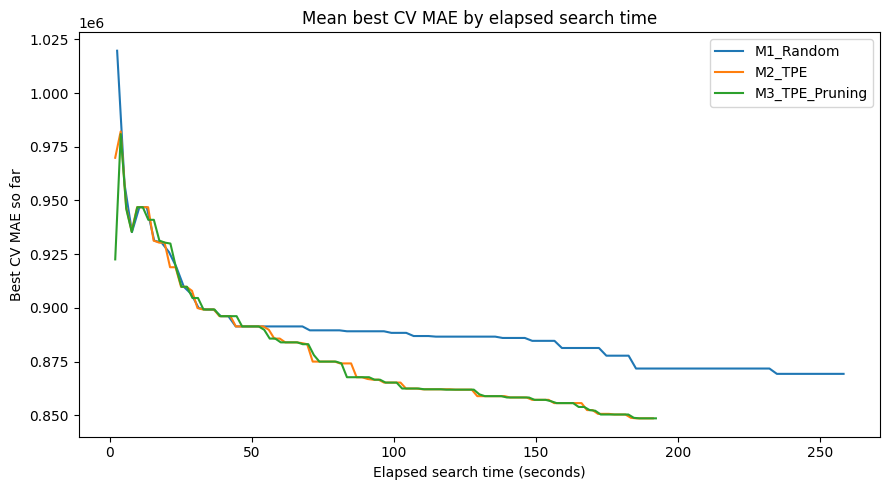

In [ ]:
# 5. Mean best-so-far CV MAE theo thời gian.
# Nội suy mỗi study lên một time grid chung để lấy trung bình.

def mean_convergence_by_time(
    convergence_data,
    methods,
    n_grid_points=100,
):
    output = []

    for method in methods:
        method_data = convergence_data[
            convergence_data["method"] == method
        ].dropna(
            subset=["elapsed_seconds", "best_cv_mae_so_far"]
        )

        max_common_time = method_data.groupby(
            "search_seed"
        )["elapsed_seconds"].max().min()

        time_grid = np.linspace(
            0,
            max_common_time,
            n_grid_points,
        )

        interpolated_runs = []

        for _, seed_data in method_data.groupby("search_seed"):
            seed_data = seed_data.sort_values("elapsed_seconds")
            x = seed_data["elapsed_seconds"].to_numpy()
            y = seed_data["best_cv_mae_so_far"].to_numpy()

            # Giữ giá trị best-so-far theo dạng step function.
            indices = np.searchsorted(
                x,
                time_grid,
                side="right",
            ) - 1

            interpolated = np.full(
                shape=len(time_grid),
                fill_value=np.nan,
                dtype=float,
            )

            valid = indices >= 0
            interpolated[valid] = y[indices[valid]]
            interpolated_runs.append(interpolated)

        mean_values = np.nanmean(
            np.vstack(interpolated_runs),
            axis=0,
        )

        for elapsed, value in zip(time_grid, mean_values):
            output.append(
                {
                    "method": method,
                    "elapsed_seconds": elapsed,
                    "mean_best_cv_mae": value,
                }
            )

    return pd.DataFrame(output)


time_convergence = mean_convergence_by_time(
    convergence_data=convergence_df,
    methods=METHODS,
)

plt.figure(figsize=(9, 5))

for method in METHODS:
    method_data = time_convergence[
        time_convergence["method"] == method
    ]
    plt.plot(
        method_data["elapsed_seconds"],
        method_data["mean_best_cv_mae"],
        label=method,
    )

plt.title("Mean best CV MAE by elapsed search time")
plt.xlabel("Elapsed search time (seconds)")
plt.ylabel("Best CV MAE so far")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Xuất prediction theo thời điểm test

Dữ liệu này cho phép phân tích MAE theo tháng/quý hoặc vẽ đường dự báo.


In [ ]:
prediction_df = pd.DataFrame(
    {
        "timestamp": test_dates,
        "y_true": np.asarray(y_test),
    }
)

for (method, seed), prediction in prediction_store.items():
    if seed is None:
        column_name = method
    else:
        column_name = f"{method}_seed_{seed}"

    prediction_df[column_name] = prediction

prediction_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)

display(prediction_df.head())
print("Saved all outputs to:", OUTPUT_DIR)


,timestamp,y_true,M0_Default,M1_Random_seed_10,M2_TPE_seed_10,M3_TPE_Pruning_seed_10,M1_Random_seed_20,M2_TPE_seed_20,M3_TPE_Pruning_seed_20,M1_Random_seed_30,...,M3_TPE_Pruning_seed_70,M1_Random_seed_80,M2_TPE_seed_80,M3_TPE_Pruning_seed_80,M1_Random_seed_90,M2_TPE_seed_90,M3_TPE_Pruning_seed_90,M1_Random_seed_100,M2_TPE_seed_100,M3_TPE_Pruning_seed_100
0,2022-01-01,2932155.47,2.021188e+06,1.930848e+06,2.116450e+06,2.116450e+06,2.061505e+06,2.095972e+06,2.095972e+06,2.083761e+06,...,2.156809e+06,1.955808e+06,1.837883e+06,1.837883e+06,1.855386e+06,2.086623e+06,2.086623e+06,2.106099e+06,2.156694e+06,2.156694e+06
1,2022-01-02,2361965.00,9.804184e+05,9.645824e+05,1.075412e+06,1.075412e+06,1.079601e+06,1.008341e+06,1.008341e+06,1.073273e+06,...,8.969197e+05,1.037157e+06,1.013729e+06,1.013729e+06,5.353842e+05,9.350933e+05,9.350933e+05,1.160199e+06,9.514663e+05,9.514663e+05
2,2022-01-03,545563.72,8.869838e+05,9.332275e+05,9.312211e+05,9.312211e+05,9.556793e+05,9.477339e+05,9.477339e+05,9.848732e+05,...,9.522408e+05,9.651226e+05,1.018216e+06,1.018216e+06,7.363185e+05,9.068761e+05,9.068761e+05,9.238913e+05,8.016759e+05,8.016759e+05
3,2022-01-04,1242319.38,8.842416e+05,8.410586e+05,8.668648e+05,8.668648e+05,9.152971e+05,7.460997e+05,7.460997e+05,9.105791e+05,...,8.596812e+05,9.915626e+05,9.567807e+05,9.567807e+05,6.862743e+05,8.807397e+05,8.807397e+05,6.632775e+05,7.817127e+05,7.817127e+05
4,2022-01-05,809977.60,8.526700e+05,9.641696e+05,7.909360e+05,7.909360e+05,9.056332e+05,7.980200e+05,7.980200e+05,9.272477e+05,...,8.854452e+05,9.906924e+05,9.505794e+05,9.505794e+05,8.502681e+05,9.276168e+05,9.276168e+05,9.009803e+05,9.473041e+05,9.473041e+05


Saved all outputs to: /content/optuna_lgbm_timeseries_results


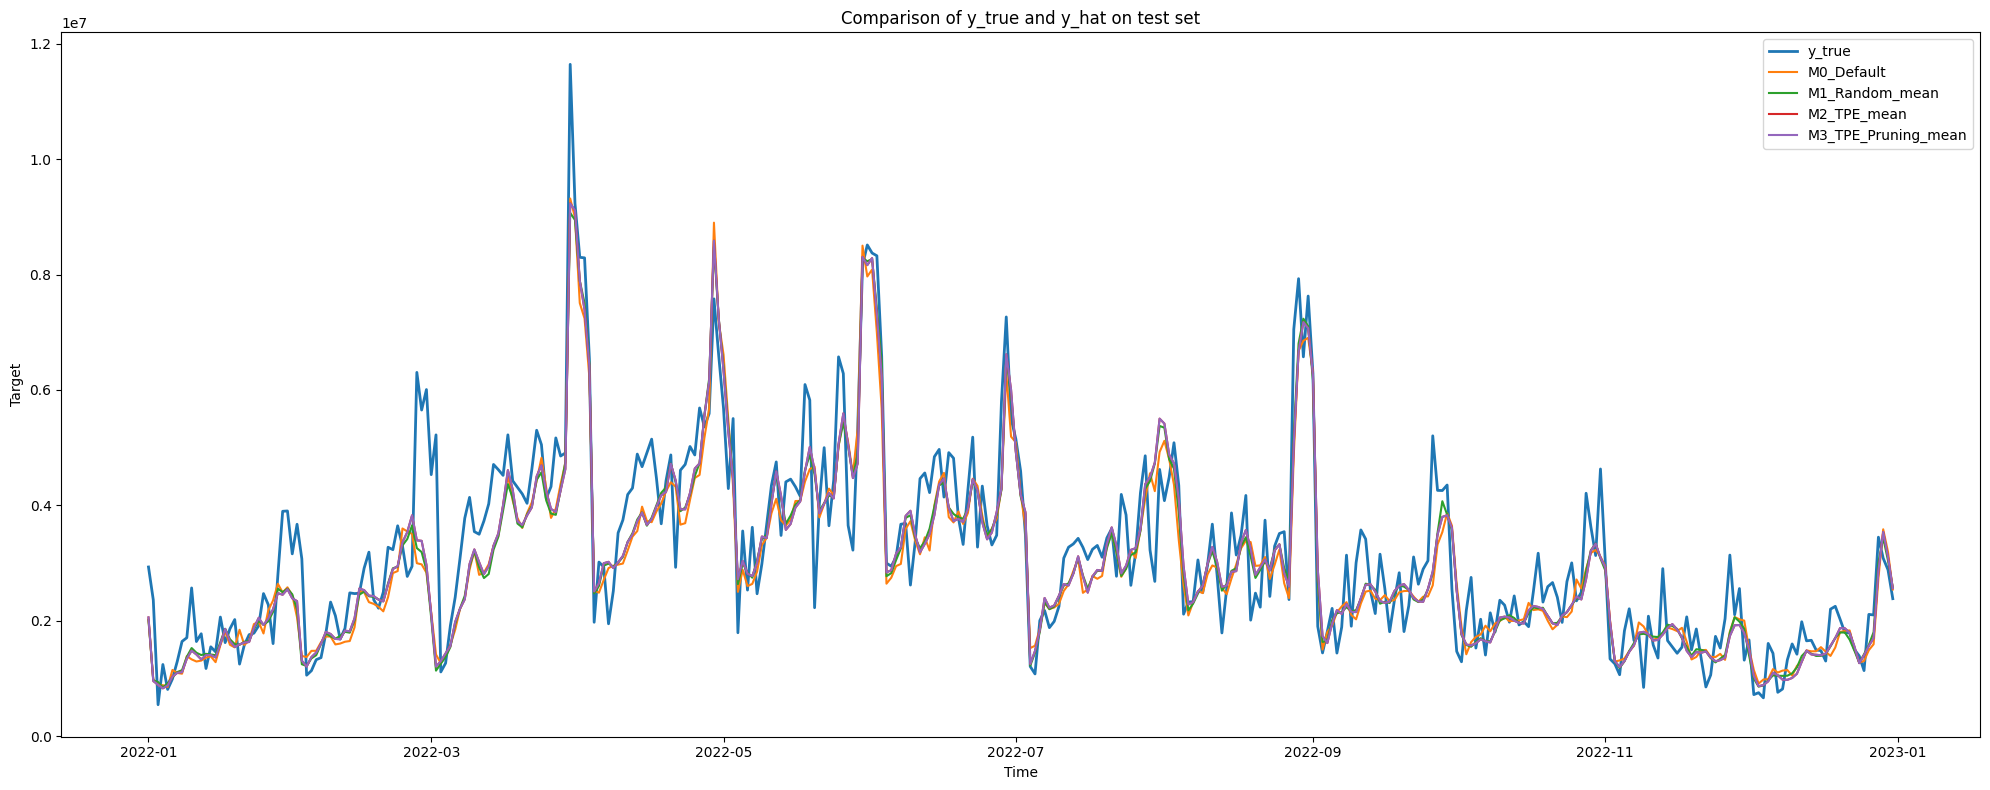

In [ ]:
plot_df = prediction_df.copy()

# Tìm các cột prediction theo từng phương pháp
m1_cols = [
    col for col in plot_df.columns
    if col.startswith("M1_Random_seed_")
]

m2_cols = [
    col for col in plot_df.columns
    if col.startswith("M2_TPE_seed_")
]

m3_cols = [
    col for col in plot_df.columns
    if col.startswith("M3_TPE_Pruning_seed_")
]

# Tính prediction trung bình theo seed
plot_df["M1_Random_mean"] = plot_df[m1_cols].mean(axis=1)
plot_df["M2_TPE_mean"] = plot_df[m2_cols].mean(axis=1)
plot_df["M3_TPE_Pruning_mean"] = plot_df[m3_cols].mean(axis=1)

plt.figure(figsize=(20, 8))

plt.plot(
    plot_df["timestamp"],
    plot_df["y_true"],
    label="y_true",
    linewidth=2,
)

plt.plot(
    plot_df["timestamp"],
    plot_df["M0_Default"],
    label="M0_Default",
)

plt.plot(
    plot_df["timestamp"],
    plot_df["M1_Random_mean"],
    label="M1_Random_mean",
)

plt.plot(
    plot_df["timestamp"],
    plot_df["M2_TPE_mean"],
    label="M2_TPE_mean",
)

plt.plot(
    plot_df["timestamp"],
    plot_df["M3_TPE_Pruning_mean"],
    label="M3_TPE_Pruning_mean",
)

plt.title("Comparison of y_true and y_hat on test set")
plt.xlabel("Time")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

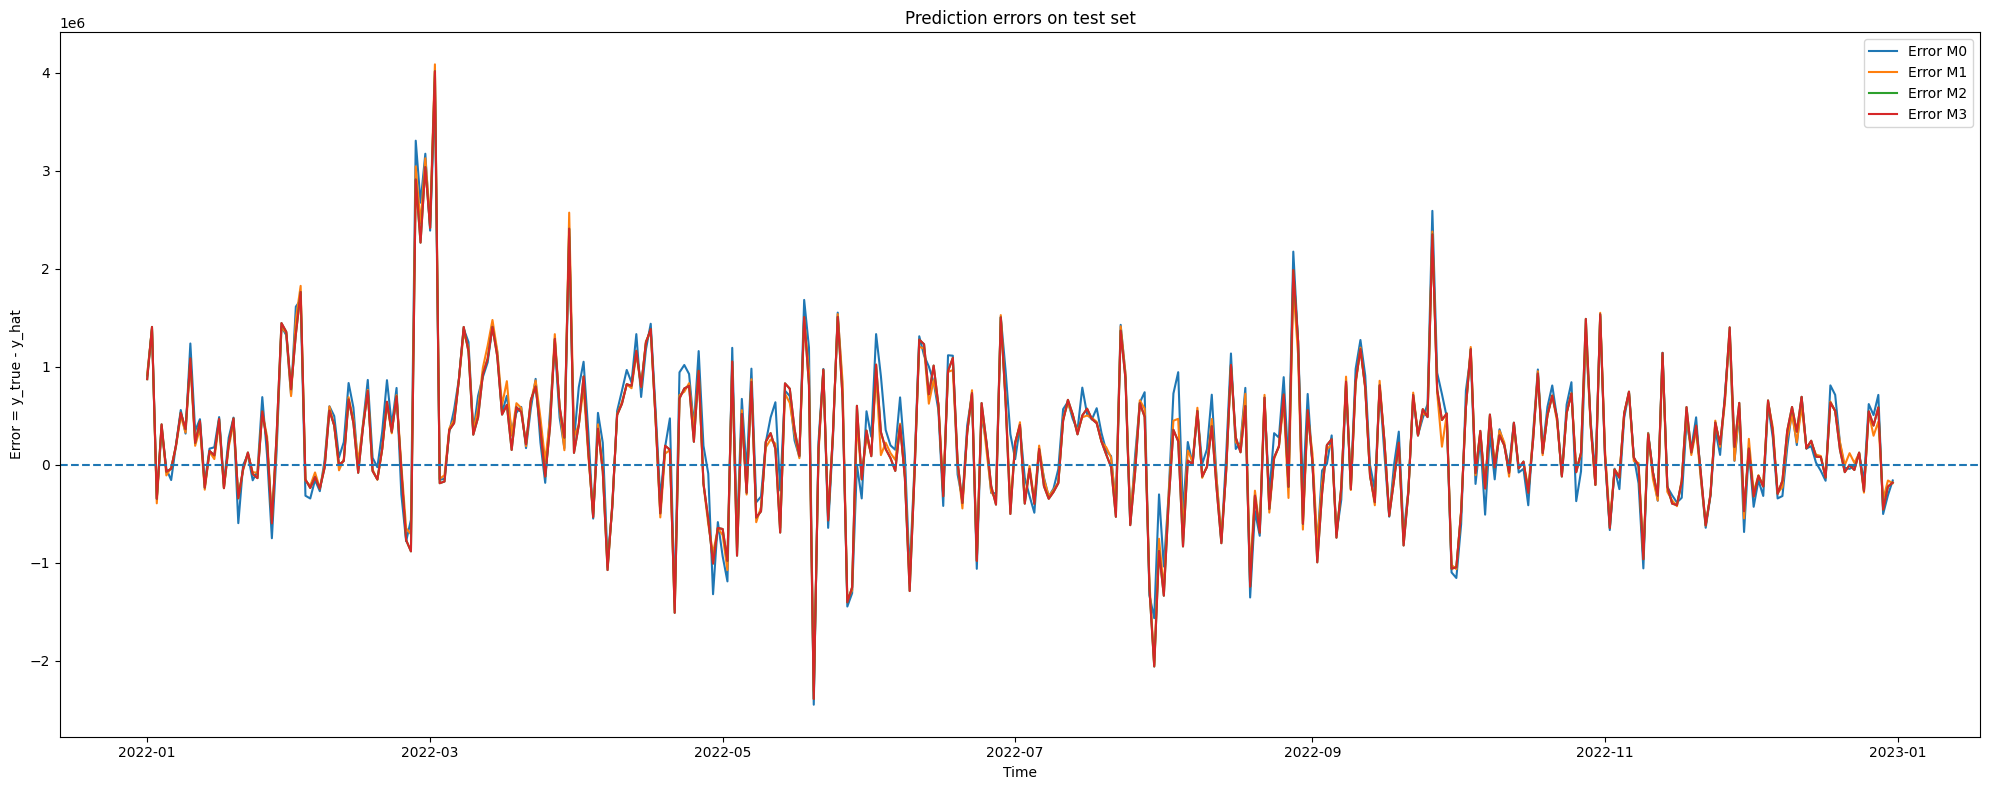

In [ ]:
plot_df["err_M0"] = plot_df["y_true"] - plot_df["M0_Default"]
plot_df["err_M1"] = plot_df["y_true"] - plot_df["M1_Random_mean"]
plot_df["err_M2"] = plot_df["y_true"] - plot_df["M2_TPE_mean"]
plot_df["err_M3"] = plot_df["y_true"] - plot_df["M3_TPE_Pruning_mean"]

plt.figure(figsize=(20, 8))

plt.plot(plot_df["timestamp"], plot_df["err_M0"], label="Error M0")
plt.plot(plot_df["timestamp"], plot_df["err_M1"], label="Error M1")
plt.plot(plot_df["timestamp"], plot_df["err_M2"], label="Error M2")
plt.plot(plot_df["timestamp"], plot_df["err_M3"], label="Error M3")

plt.axhline(0, linestyle="--")

plt.title("Prediction errors on test set")
plt.xlabel("Time")
plt.ylabel("Error = y_true - y_hat")
plt.legend()
plt.tight_layout()
plt.show()

## Kết luận

Kết quả thực nghiệm cho thấy việc tối ưu siêu tham số bằng Optuna giúp cải thiện hiệu năng của LightGBM so với cấu hình mặc định trên cả ba chỉ số đánh giá. So với M0, RandomSampler giảm khoảng **5,30% MAE**, **3,31% RMSE** và **5,66% sMAPE**; đây cũng là phương pháp đạt **MAE và sMAPE tốt nhất** trên tập test. TPESampler đạt **RMSE thấp nhất** và có độ biến thiên giữa các seed nhỏ hơn RandomSampler, cho thấy kết quả ổn định hơn, nhưng không vượt trội đồng thời trên tất cả các chỉ số.

Việc kết hợp TPE với pruning đã loại bỏ trung bình **11,4/50 trial**, nhưng chỉ giảm khoảng **0,88% thời gian tìm kiếm trung bình** và không làm thay đổi kết quả dự báo cuối cùng so với TPE không pruning. Như vậy, trong phạm vi dữ liệu, không gian tìm kiếm và giới hạn 50 trial của notebook, **hyperparameter tuning mang lại cải thiện rõ ràng**, nhưng **TPE chưa thể hiện ưu thế toàn diện so với Random Search**, còn **fold-level pruning chưa đem lại lợi ích tính toán đáng kể**.